## Exercises
1. Train a single decision tree on a 2D dataset with 3 classes. Manually trace the splits and draw the rectangular decision boundaries. Compare the boundaries at max_depth=2 vs max_depth=10.
2. Implement variance reduction splitting for regression trees. Generate y = sin(x) + noise for 200 points and fit your regression tree. Plot the tree's piecewise-constant predictions against the true curve.
3. Build a random forest with 1, 5, 10, 50, and 200 trees. Plot training accuracy and test accuracy vs number of trees. Observe that test accuracy plateaus but does not decrease (forests resist overfitting).
4. Compare Gini impurity vs entropy as split criteria on 5 different datasets. Measure accuracy and tree depth. In most cases, they produce nearly identical results. Explain why.
5. Implement permutation importance. Compare it with MDI importance on a dataset where one feature is random noise but has high cardinality. MDI will rank the noise feature highly. Permutation importance will not.


### 1. Train a single decision tree on a 2D dataset with 3 classes. Manually trace the splits and draw the rectangular decision boundaries. Compare the boundaries at max_depth=2 vs max_depth=10.


In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()


In [35]:
X=iris["data"]
y=iris["target"]

In [36]:
X_2D = X[:,:2]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_2D, y, test_size=0.33, random_state=42)

In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
dt_2=DecisionTreeClassifier(max_depth=2)
dt_10=DecisionTreeClassifier(max_depth=10)

In [40]:
dt_2.fit(X_train,y_train)
dt_10.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [41]:
dt_2.score(X_test,y_test)

0.76

In [42]:
dt_10.score(X_test,y_test)

0.76

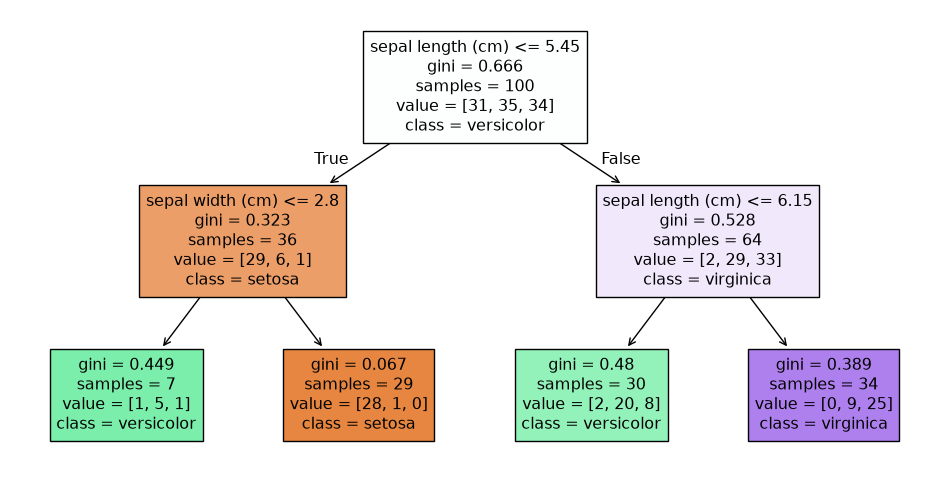

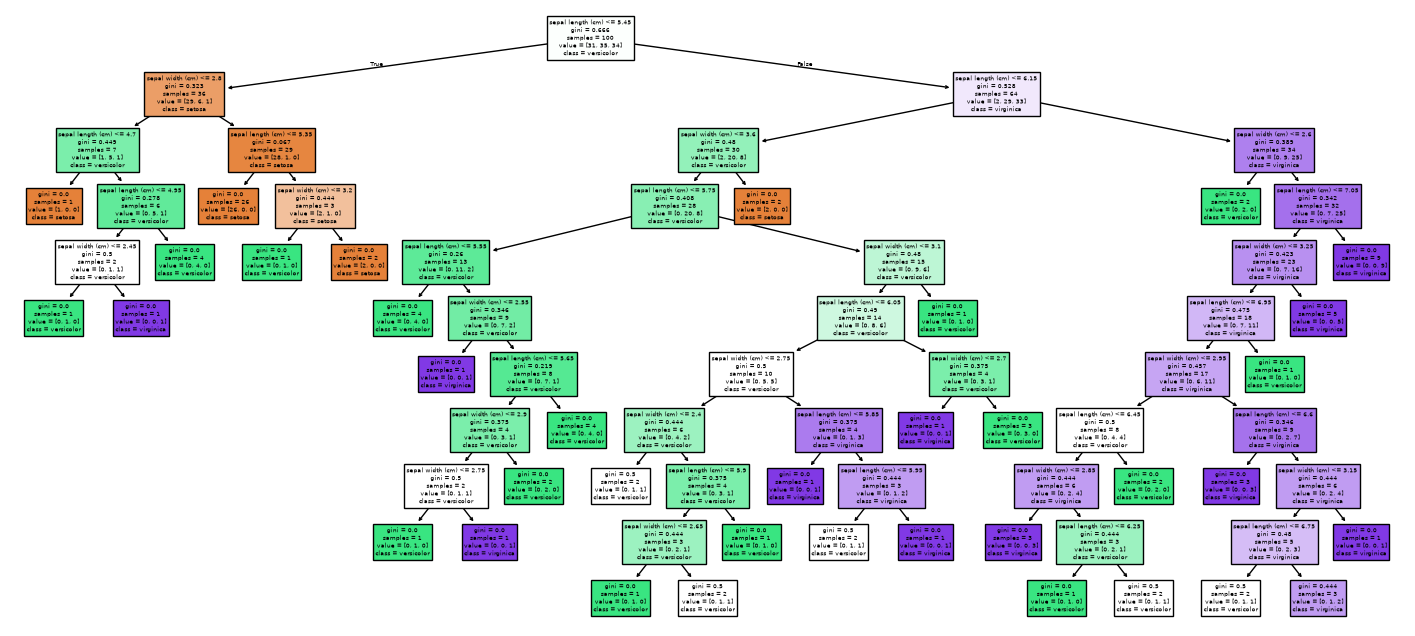

In [49]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(dt_2, filled=True, feature_names=['sepal length (cm)','sepal width (cm)'] ,
          class_names=['setosa', 'versicolor', 'virginica']
)
plt.show()

plt.figure(figsize=(18,8))
plot_tree(dt_10, filled=True, feature_names=['sepal length (cm)','sepal width (cm)'] ,
          class_names=['setosa', 'versicolor', 'virginica']
)
plt.show()


In [53]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [50]:
# on full class data with 4 feature
X=iris["data"]
y=iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X_2D, y, test_size=0.33, random_state=42)

tree2=DecisionTreeClassifier(max_depth=2)
tree10=DecisionTreeClassifier(max_depth=10)

tree2.fit(X_train,y_train)
tree10.fit(X_train,y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [51]:
tree2.score(X_test,y_test)

0.76

In [52]:
tree10.score(X_test,y_test)


0.72

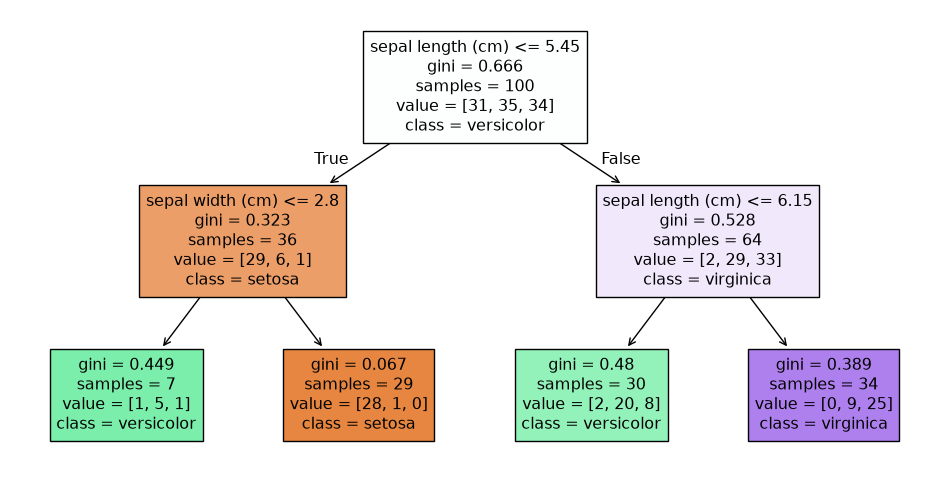

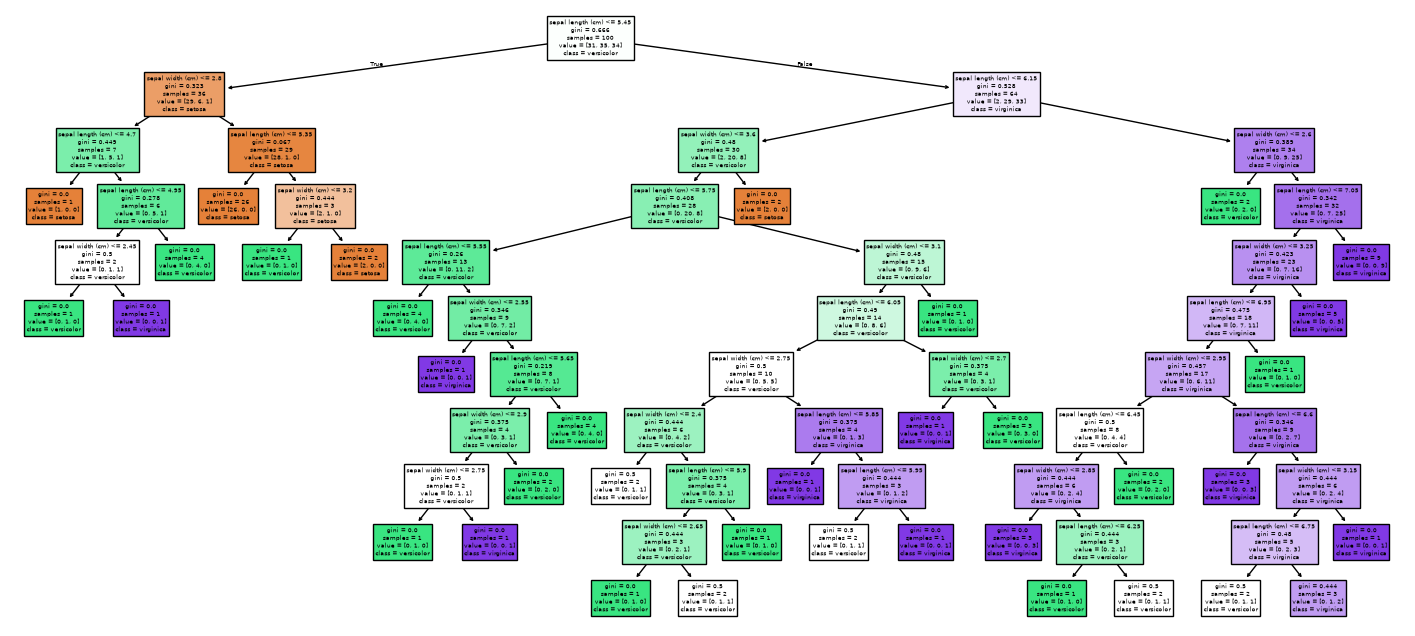

In [54]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(dt_2, filled=True, feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)'],
          class_names=['setosa', 'versicolor', 'virginica']
)
plt.show()

plt.figure(figsize=(18,8))
plot_tree(dt_10, filled=True, feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)'],
          class_names=['setosa', 'versicolor', 'virginica']
)
plt.show()


### 2. Implement variance reduction splitting for regression trees. Generate y = sin(x) + noise for 200 points and fit your regression tree. Plot the tree's piecewise-constant predictions against the true curve.


In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# ----------------------------
# Generate data
# ----------------------------

np.random.seed(42)

X = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 200)



In [87]:

# ----------------------------
# Train Regression Tree
# sklearn uses variance reduction (MSE) by default
# ----------------------------

model = DecisionTreeRegressor(
    criterion="squared_error",   # variance reduction
    max_depth=5,
    random_state=42
)


In [88]:
model.fit(X,y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [89]:
y_pred = model.predict(X)


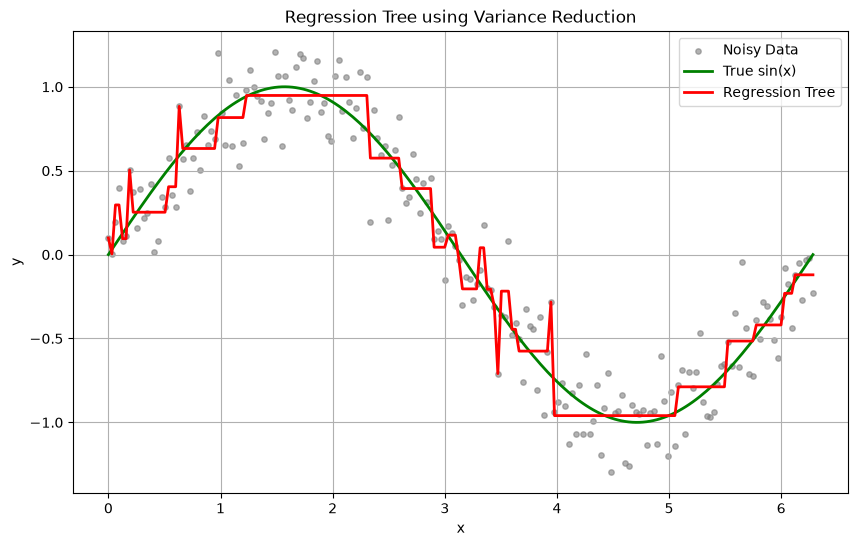

In [90]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color="gray", s=15, alpha=0.6, label="Noisy Data")
plt.plot(X, np.sin(X), color="green", linewidth=2, label="True sin(x)")
plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Tree")

plt.title("Regression Tree using Variance Reduction")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

### 3. Build a random forest with 1, 5, 10, 50, and 200 trees. Plot training accuracy and test accuracy vs number of trees. Observe that test accuracy plateaus but does not decrease (forests resist overfitting).


In [66]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
estimators = [1,5,10,50,200]
trainning_acc=[]
test_acc=[]

In [68]:
for estimator in estimators:
    rf=RandomForestClassifier(n_estimators=estimator)
    rf.fit(X_train,y_train)
    
    # metrices
    # traning acc
    tr_acc=rf.score(X_train,y_train)
    trainning_acc.append(tr_acc)

    # test acc
    ts_acc=rf.score(X_test,y_test)
    test_acc.append(ts_acc)

    print(f"Estimator : {estimator},Training Accuracy: {tr_acc},Test Acccuracy : {ts_acc}")

Estimator : 1,Training Accuracy: 0.84,Test Acccuracy : 0.7
Estimator : 5,Training Accuracy: 0.9,Test Acccuracy : 0.74
Estimator : 10,Training Accuracy: 0.95,Test Acccuracy : 0.8
Estimator : 50,Training Accuracy: 0.96,Test Acccuracy : 0.78
Estimator : 200,Training Accuracy: 0.96,Test Acccuracy : 0.78


In [69]:
test_acc


[0.7, 0.74, 0.8, 0.78, 0.78]

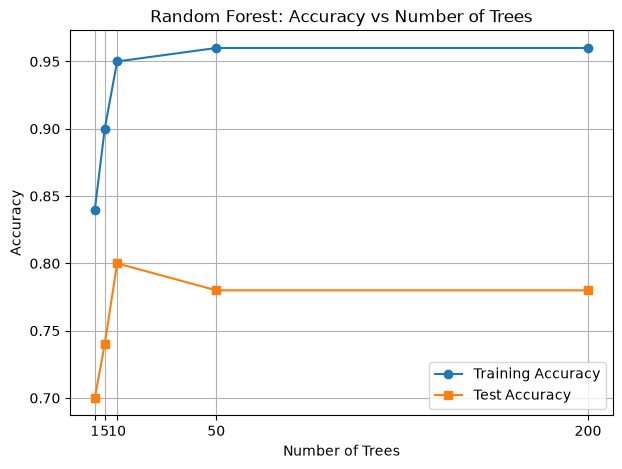

In [70]:
plt.figure(figsize=(7,5))

plt.plot(estimators, trainning_acc, marker="o", label="Training Accuracy")
plt.plot(estimators, test_acc, marker="s", label="Test Accuracy")

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest: Accuracy vs Number of Trees")
plt.xticks(estimators)
plt.grid(True)
plt.legend()

plt.show()

### 4. Compare Gini impurity vs entropy as split criteria on 5 different datasets. Measure accuracy and tree depth. In most cases, they produce nearly identical results. Explain why.


In [71]:
import pandas as pd

from sklearn.datasets import (
    load_iris,
    load_wine,
    load_breast_cancer,
    load_digits,
    make_classification
)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [72]:
datasets = [
    ("Iris", *load_iris(return_X_y=True)),
    ("Wine", *load_wine(return_X_y=True)),
    ("Breast Cancer", *load_breast_cancer(return_X_y=True)),
    ("Digits", *load_digits(return_X_y=True)),
    ("Synthetic", *make_classification(
        n_samples=1000,
        n_features=20,
        n_informative=10,
        n_classes=3,
        random_state=42
    ))
]

In [73]:
results = []

for name, X, y in datasets:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    for criterion in ["gini", "entropy"]:

        model = DecisionTreeClassifier(
            criterion=criterion,
            random_state=42
        )

        model.fit(X_train, y_train)

        results.append([
            name,
            criterion,
            model.score(X_test, y_test),
            model.get_depth()
        ])

df = pd.DataFrame(
    results,
    columns=["Dataset", "Criterion", "Accuracy", "Tree Depth"]
)

print(df)

         Dataset Criterion  Accuracy  Tree Depth
0           Iris      gini  0.933333           5
1           Iris   entropy  0.888889           6
2           Wine      gini  0.962963           4
3           Wine   entropy  0.907407           3
4  Breast Cancer      gini  0.918129           6
5  Breast Cancer   entropy  0.947368           7
6         Digits      gini  0.851852          11
7         Digits   entropy  0.827778          10
8      Synthetic      gini  0.676667          14
9      Synthetic   entropy  0.636667          14


Explanation.

- Both measure node impurity.
- Both prefer splits producing pure child nodes.
- Candidate split ranking usually same.
- Therefore selected splits almost identical.
- Tree depth usually same or differs by 1-2.
- Accuracy difference usually 0-2%.
- Gini slightly faster. No logarithm.
- Entropy uses log2, slightly more expensive.
- No criterion consistently better across all datasets. Usually nearly identical performance.

### 5. Implement permutation importance. Compare it with MDI importance on a dataset where one feature is random noise but has high cardinality. MDI will rank the noise feature highly. Permutation importance will not.


In [74]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [75]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [76]:
np.random.seed(42)

X["random_noise"] = np.random.permutation(len(X))

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [78]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [80]:
print("Train:", model.score(X_train, y_train))
print("Test :", model.score(X_test, y_test))

Train: 1.0
Test : 0.9473684210526315


In [79]:
mdi = pd.DataFrame({
    "Feature": X.columns,
    "MDI": model.feature_importances_
})

mdi = mdi.sort_values("MDI", ascending=False)

print(mdi.head(10))

                 Feature       MDI
27  worst concave points  0.135372
22       worst perimeter  0.132324
20          worst radius  0.127825
23            worst area  0.084719
7    mean concave points  0.075285
3              mean area  0.064876
0            mean radius  0.059367
2         mean perimeter  0.047235
26       worst concavity  0.043647
6         mean concavity  0.037491


In [81]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm = pd.DataFrame({
    "Feature": X.columns,
    "Permutation": perm.importances_mean
})

perm = perm.sort_values("Permutation", ascending=False)

print(perm.head(10))

                    Feature  Permutation
21            worst texture     0.013450
11            texture error     0.009942
1              mean texture     0.008187
12          perimeter error     0.005263
6            mean concavity     0.004678
7       mean concave points     0.004678
24         worst smoothness     0.002924
13               area error     0.002339
22          worst perimeter     0.002339
29  worst fractal dimension     0.001754


In [82]:
mdi

,Feature,MDI
27,worst concave points,0.135372
22,worst perimeter,0.132324
20,worst radius,0.127825
23,worst area,0.084719
7,mean concave points,0.075285
3,mean area,0.064876
0,mean radius,0.059367
2,mean perimeter,0.047235
26,worst concavity,0.043647
6,mean concavity,0.037491


In [83]:
perm

,Feature,Permutation
21,worst texture,0.013450
11,texture error,0.009942
1,mean texture,0.008187
12,perimeter error,0.005263
6,mean concavity,0.004678
7,mean concave points,0.004678
24,worst smoothness,0.002924
13,area error,0.002339
22,worst perimeter,0.002339
29,worst fractal dimension,0.001754


In [84]:
result = mdi.merge(perm, on="Feature")

result = result.sort_values("MDI", ascending=False)

print(result)

                    Feature       MDI  Permutation
0      worst concave points  0.135372    -0.005263
1           worst perimeter  0.132324     0.002339
2              worst radius  0.127825     0.000585
3                worst area  0.084719     0.001170
4       mean concave points  0.075285     0.004678
5                 mean area  0.064876     0.000585
6               mean radius  0.059367     0.000000
7            mean perimeter  0.047235     0.000000
8           worst concavity  0.043647     0.001170
9            mean concavity  0.037491     0.004678
10               area error  0.023938     0.002339
11         mean compactness  0.019629     0.000000
12            worst texture  0.014545     0.013450
13        worst compactness  0.014329     0.001170
14         worst smoothness  0.013405     0.002924
15             mean texture  0.012057     0.008187
16             radius error  0.011166     0.000000
17          perimeter error  0.010413     0.005263
18           worst symmetry  0.

In [85]:
print(result[result["Feature"] == "random_noise"])

         Feature       MDI  Permutation
23  random_noise  0.005686          0.0
